0. Veri Setinin Hazırlanması

In [1]:
#Kütüphaneleri yüklüyoruz
#Pandas ve Numpy

import pandas as pd
import numpy as np

#Görselleştirme Kütüphaneleri

import matplotlib.pyplot as plt
import seaborn as sns

#Diğer örnek görselleştirme kütüphaneleri
#ggplot
#Bokeh
#Plotly

In [2]:
#Veri setini notebook içine dahil edelim

df_ = pd.read_csv(filepath_or_buffer = "/kaggle/input/datasets/hummaamqaasim/jobs-in-data/jobs_in_data.csv")
df=df_.copy()

In [3]:
#Veri setinde rastgele eksik veriler oluşturalım.
import random

def add_random_missing_values(dataframe:pd.DataFrame,
                             missing_rate:float=0.05,
                             seed:random=42)->pd.DataFrame:


#Get copy of dataframe
    df_missing = dataframe.copy()

#Obtain size of datafdrame and number total number of missing values
    df_size=dataframe.size
    num_missing=int(df_size*missing_rate)

#Set seed
    if seed:
        random.seed(seed)


#Get random row and column indexes to turn them NaN

    for _ in range(num_missing):
        row_idx =random.randint(0, dataframe.shape[0]-1)
        col_idx =random.randint(0, dataframe.shape[1] -1)

        df_missing.iat[row_idx, col_idx] =np.nan
    return df_missing

df=add_random_missing_values(dataframe=df,
                             missing_rate=0.03)

    


1.Veriye İlk Bakış

In [4]:
#Veri setinin ilk 3 gözlemini görelim, default ilk 5 dir.
df.head(3)

#Sondan 3 gözlem için tail() metodu kullanılabilir
#df.tail()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023.0,Data DevOps Engineer,Data Engineering,EUR,88000.0,95012.0,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023.0,Data Architect,Data Architecture and Modeling,USD,186000.0,186000.0,United States,Senior,Full-time,In-person,United States,M
2,2023.0,Data Architect,Data Architecture and Modeling,USD,81800.0,81800.0,United States,Senior,Full-time,In-person,United States,M


In [5]:
#Veri setinde satır ve sütun sayılarını .shape kullanarak görebiliriz. 
#sonunda parantez yoksa bir attribute dur. Parantez varsa df den türeyen method olur.
df.shape

(9355, 12)

In [6]:
#Veri setindeki kolonlar
print(list(df.columns), '\n')

#len() fonksiyonu ile toplam kolon sayısını öğreniyoruz
print(f"Veri seti içerisindeki toplam {len(df.columns)} kolon vardır.\n")

#Çoğu zaman kullandığımız attribute ve fonksiyonların sonuçlarının hangi tipte veri döndürdüğünü gözlemlemek kod üzerinde hakimiyet kurmak için önemlidir
print(f"df.columns'un döndüğü veri tipi: {type(df.columns)}\n")

['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size'] 

Veri seti içerisindeki toplam 12 kolon vardır.

df.columns'un döndüğü veri tipi: <class 'pandas.core.indexes.base.Index'>



In [7]:
#Veri seti ile ilgili bilgiler
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           9094 non-null   float64
 1   job_title           9086 non-null   object 
 2   job_category        9079 non-null   object 
 3   salary_currency     9094 non-null   object 
 4   salary              9060 non-null   float64
 5   salary_in_usd       9068 non-null   float64
 6   employee_residence  9091 non-null   object 
 7   experience_level    9062 non-null   object 
 8   employment_type     9089 non-null   object 
 9   work_setting        9078 non-null   object 
 10  company_location    9080 non-null   object 
 11  company_size        9060 non-null   object 
dtypes: float64(3), object(9)
memory usage: 877.2+ KB


In [8]:
categorical_features=[]
numerical_features=[]

for col in df.columns:
    if(df[col].dtype=="object") or (df[col].dtype=="categorical"):
        categorical_features.append(col)
    else:
        numerical_features.append(col)

In [9]:
categorical_features, numerical_features

(['job_title',
  'job_category',
  'salary_currency',
  'employee_residence',
  'experience_level',
  'employment_type',
  'work_setting',
  'company_location',
  'company_size'],
 ['work_year', 'salary', 'salary_in_usd'])

In [10]:
#Categorical_features içerisindeki kolonların üzerinde dönen veri setinde her bu kolonlara ait verilerin tipini categorik olarak çevirdim 
#Çünkü categorical veri tipi arka planda obje dışında farklı bilgilerde de tutar.
#Sadece bezersiz değerleri (kategorileri) tutar ve her satırı birer sayısal anahtar (kod) ile temsil eder
#Yani kategorik veri tipi arka planda bir tam sayı dizisi ve bu sayıların ne anlama geldiğini söleyen bir etiket listesi tutar 
for col in df.columns:
    if col in categorical_features:

        df[col]=pd.Categorical(df[col])

In [11]:
#object tipini category tipine dönüştürmedeki amaç: bilgisayarın kelimelerle boğulup yavaşlamasındiye
#kelimeleri arka planda sayılara dönüştürererek yer kazanıyoruz ve hızlanıyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           9094 non-null   float64 
 1   job_title           9086 non-null   category
 2   job_category        9079 non-null   category
 3   salary_currency     9094 non-null   category
 4   salary              9060 non-null   float64 
 5   salary_in_usd       9068 non-null   float64 
 6   employee_residence  9091 non-null   category
 7   experience_level    9062 non-null   category
 8   employment_type     9089 non-null   category
 9   work_setting        9078 non-null   category
 10  company_location    9080 non-null   category
 11  company_size        9060 non-null   category
dtypes: category(9), float64(3)
memory usage: 313.4 KB


In [12]:
df['company_size'][:3]

0    L
1    M
2    M
Name: company_size, dtype: category
Categories (3, object): ['L', 'M', 'S']

In [13]:
df.describe().T # T eklentisi elde edeceğimiz çıktıyı transpose eder.

,count,mean,std,min,25%,50%,75%,max
work_year,9094.0,2022.760062,0.520180,2020.0,2023.0,2023.0,2023.0,2023.0
salary,9060.0,149971.803201,63736.433969,14000.0,105200.0,143805.0,187000.0,450000.0
salary_in_usd,9068.0,150281.393361,63154.534781,15000.0,105700.0,143225.0,186300.0,450000.0


In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,9094.0,NaN,NaN,NaN,2022.760062,0.52018,2020.0,2023.0,2023.0,2023.0,2023.0
job_title,9086,125,Data Engineer,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_category,9079,10,Data Science and Research,2937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_currency,9094,11,USD,8350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,9060.0,NaN,NaN,NaN,149971.803201,63736.433969,14000.0,105200.0,143805.0,187000.0,450000.0
salary_in_usd,9068.0,NaN,NaN,NaN,150281.393361,63154.534781,15000.0,105700.0,143225.0,186300.0,450000.0
employee_residence,9091,82,United States,7857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,9062,4,Senior,6484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,9089,4,Full-time,9044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_setting,9078,3,In-person,5563,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Eksik Veri Analizi

In [15]:
#2.1 Eksik Verilerin Gözlemlenmesi
df.isna().sum()

work_year             261
job_title             269
job_category          276
salary_currency       261
salary                295
salary_in_usd         287
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [16]:
#Veri setindeki toplam eksik değer sayısını görmek için tekrar sum() fonksiyonu ekleyebiliriz
df.isna().sum().sum()

np.int64(3319)

In [17]:
#Veri setinde eksik olmayan ve eksik olan gözlemler
print(f"Veri setinde toplam {df.notnull().sum().sum()} adet eksik olmayan, {df.isnull().sum().sum()} eksik gözlem var")

Veri setinde toplam 108941 adet eksik olmayan, 3319 eksik gözlem var


In [18]:
#Veri setinde en az bir gözlemi eksik olan kayıtlar da olabilir
df[df.isnull().any(axis=1)][:5]

#hiç eksik olmayan kayıtlarda isnull() yerine notnull() metodunu kullanıyorum.
# df[df.notnull().any(axis=1)][:5]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
4,2023.0,Data Scientist,NaN,USD,93300.0,93300.0,United States,Senior,Full-time,In-person,United States,M
6,2023.0,Data Scientist,Data Science and Research,USD,NaN,100000.0,United States,Senior,Full-time,Remote,United States,M
9,2023.0,Data Engineer,Data Engineering,USD,210000.0,210000.0,United States,Executive,Full-time,NaN,United States,M
11,2023.0,Machine Learning Engineer,Machine Learning and AI,USD,224400.0,NaN,NaN,Senior,Full-time,In-person,United States,M
20,NaN,Analytics Engineer,Leadership and Management,USD,120000.0,120000.0,United States,Mid-level,Full-time,In-person,United States,M


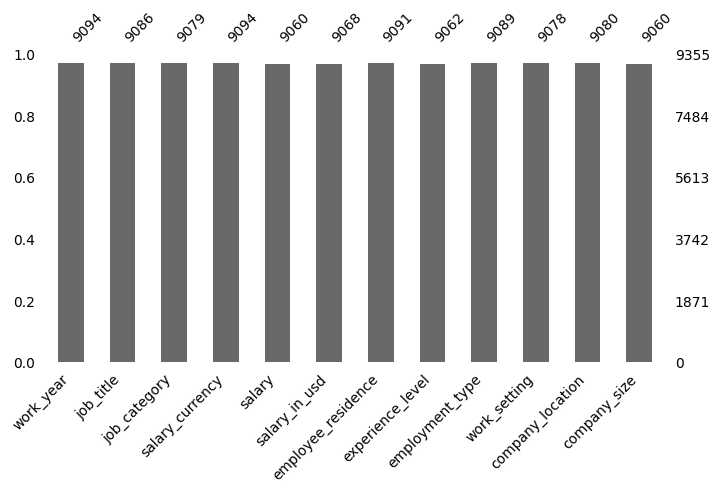

In [19]:
#!pip install missingno -> missingno kütüphanesini kullanabilmek için öncelikle yüklemeniz lazım.
!pip install missingno
import missingno as msno

msno.bar(df = df,
         figsize = (8, 4),
         fontsize = 10);

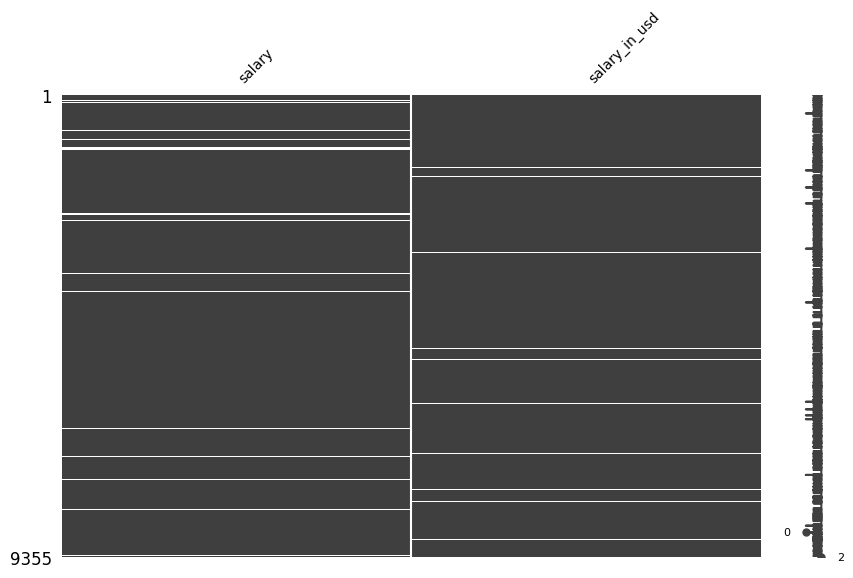

In [20]:
#msno.matrix(),değişkenlerde bulunan eksik değerlerin ilişkili olup olmadığını görsel yolla tespit etmek için kullanılır
#siyah bölümler eksik olmayan, beyaz bölümler eksik olanlar
#bir kolonda eksiklik varken diğer kolonda eksiklik var mı karşılaştırması yapılır
#Eğer iki kolonda da aynı hizada eksiklik varsa birbiriyle ilişkili olmaları muhtemel olabilir
msno.matrix(df=df[['salary', 'salary_in_usd']],
           figsize=(10,6),
           fontsize=10);


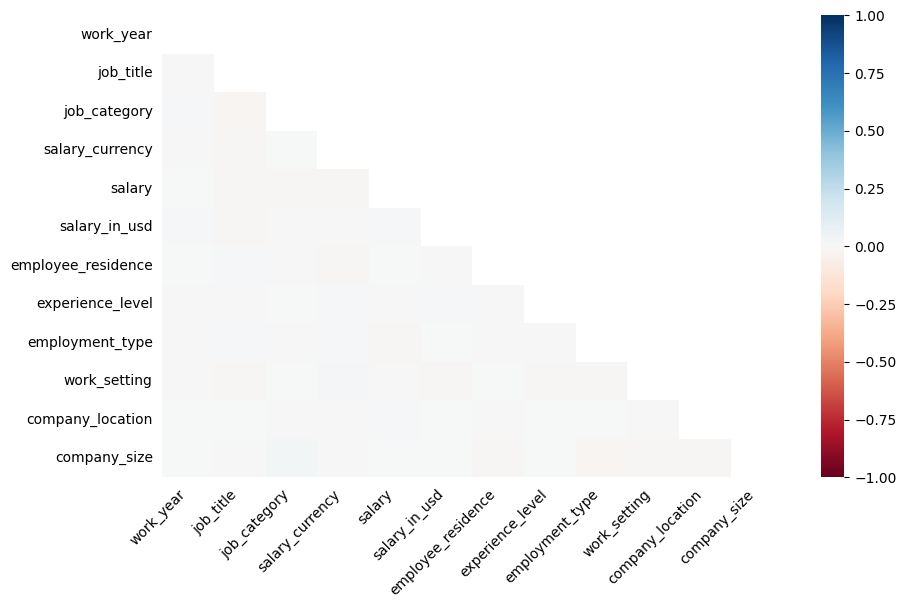

In [21]:
# Nullity Correlation (Heatmap)
# 1'e ne kadar yakınsa, ilişki ihtimali o kadar yüksek.
# 0 ise, birbirlerini etkileyen bir durum yoktur.
msno.heatmap(df=df,
            figsize=(10,6),
            fontsize=(10));



In [22]:
#2.2 Eksik Verilerin Silinmesi
df.dropna(inplace=False)[:5]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023.0,Data DevOps Engineer,Data Engineering,EUR,88000.0,95012.0,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023.0,Data Architect,Data Architecture and Modeling,USD,186000.0,186000.0,United States,Senior,Full-time,In-person,United States,M
2,2023.0,Data Architect,Data Architecture and Modeling,USD,81800.0,81800.0,United States,Senior,Full-time,In-person,United States,M
3,2023.0,Data Scientist,Data Science and Research,USD,212000.0,212000.0,United States,Senior,Full-time,In-person,United States,M
5,2023.0,Data Scientist,Data Science and Research,USD,130000.0,130000.0,United States,Senior,Full-time,Remote,United States,M


In [23]:
#tüm değerleri eksik olan bir gözlemi silersek
df.dropna(how='all')[:5]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023.0,Data DevOps Engineer,Data Engineering,EUR,88000.0,95012.0,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023.0,Data Architect,Data Architecture and Modeling,USD,186000.0,186000.0,United States,Senior,Full-time,In-person,United States,M
2,2023.0,Data Architect,Data Architecture and Modeling,USD,81800.0,81800.0,United States,Senior,Full-time,In-person,United States,M
3,2023.0,Data Scientist,Data Science and Research,USD,212000.0,212000.0,United States,Senior,Full-time,In-person,United States,M
4,2023.0,Data Scientist,NaN,USD,93300.0,93300.0,United States,Senior,Full-time,In-person,United States,M


In [24]:
#Değişken bazında silmek için
df.dropna(axis=1)

""
0
1
2
3
4
...
9350
9351
9352
9353


In [25]:
df

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023.0,Data DevOps Engineer,Data Engineering,EUR,88000.0,95012.0,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023.0,Data Architect,Data Architecture and Modeling,USD,186000.0,186000.0,United States,Senior,Full-time,In-person,United States,M
2,2023.0,Data Architect,Data Architecture and Modeling,USD,81800.0,81800.0,United States,Senior,Full-time,In-person,United States,M
3,2023.0,Data Scientist,Data Science and Research,USD,212000.0,212000.0,United States,Senior,Full-time,In-person,United States,M
4,2023.0,Data Scientist,NaN,USD,93300.0,93300.0,United States,Senior,Full-time,In-person,United States,M
...,...,...,...,...,...,...,...,...,...,...,...,...
9350,2021.0,Data Specialist,Data Management and Strategy,USD,165000.0,165000.0,United States,Senior,Full-time,Remote,United States,L
9351,2020.0,Data Scientist,Data Science and Research,USD,412000.0,412000.0,United States,Senior,Full-time,Remote,United States,L
9352,2021.0,Principal Data Scientist,Data Science and Research,USD,151000.0,151000.0,United States,Mid-level,Full-time,Remote,United States,L
9353,2020.0,Data Scientist,Data Science and Research,USD,105000.0,105000.0,United States,Entry-level,Full-time,Remote,United States,S


In [26]:
#2.3 Yöntem: Eksik Verilerin Doldurulması
df_fillna=df.copy()
df_fillna.head(3)


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023.0,Data DevOps Engineer,Data Engineering,EUR,88000.0,95012.0,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023.0,Data Architect,Data Architecture and Modeling,USD,186000.0,186000.0,United States,Senior,Full-time,In-person,United States,M
2,2023.0,Data Architect,Data Architecture and Modeling,USD,81800.0,81800.0,United States,Senior,Full-time,In-person,United States,M


In [27]:
df_fillna.isna().sum()

work_year             261
job_title             269
job_category          276
salary_currency       261
salary                295
salary_in_usd         287
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [28]:
#2.3.1 Sayısal Değişkenlerin Doldurulması
mean_salary= df_fillna['salary'].mean()

df_fillna['salary'].fillna(value=mean_salary, inplace=True)
df_fillna.isna().sum()

/tmp/ipykernel_16/2378349319.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fillna['salary'].fillna(value=mean_salary, inplace=True)


work_year             261
job_title             269
job_category          276
salary_currency       261
salary                  0
salary_in_usd         287
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [29]:
#Döngü ile tüm kolonlar gezilerek doldurma

to_be_filled =numerical_features[1:]

for col in to_be_filled:
    df_fillna[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_16/2653409503.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fillna[col].fillna(df[col].mean(), inplace=True)


In [30]:
df_fillna.isna().sum()

work_year             261
job_title             269
job_category          276
salary_currency       261
salary                  0
salary_in_usd           0
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,9094.0,2022.760062,0.520180,2020.0,2023.0,2023.0,2023.0,2023.0
salary,9060.0,149971.803201,63736.433969,14000.0,105200.0,143805.0,187000.0,450000.0
salary_in_usd,9068.0,150281.393361,63154.534781,15000.0,105700.0,143225.0,186300.0,450000.0


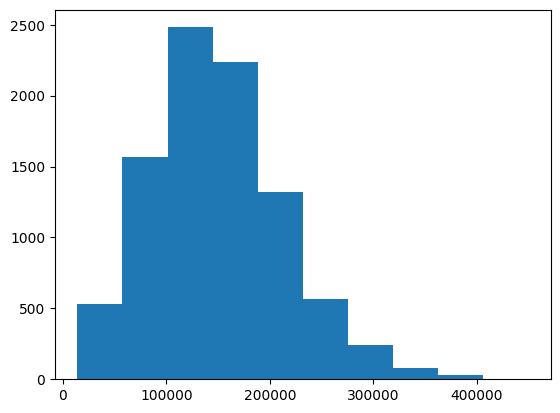

In [32]:
#Sayısal değişkenin dağılımını görmek için histogram kullanabiliriz
plt.hist(df['salary'])
plt.show()

In [33]:
#2.3.3 Kategorik Kırılım ile Doldurma
#mode değer en çok tekrar eden değer

#work_setting değişkeninde toplam kaç adet eksik değer olduğunu görelim
df_fillna['work_setting'].isna().sum()

#work_setting değişkenini mode değeri ile dolduralım
work_setting_mode=df_fillna['work_setting'].mode()
df_fillna['work_setting']=df_fillna['work_setting'].fillna(value=work_setting_mode[0])

#work_setting değişkeninde toplam kaç adet eksik değer olduğunu tekrar görelim
df_fillna.isna().sum()



work_year             261
job_title             269
job_category          276
salary_currency       261
salary                  0
salary_in_usd           0
employee_residence    264
experience_level      293
employment_type       266
work_setting            0
company_location      275
company_size          295
dtype: int64

In [34]:
df_fillna[["job_category"]]

,job_category
0,Data Engineering
1,Data Architecture and Modeling
2,Data Architecture and Modeling
3,Data Science and Research
4,NaN
...,...
9350,Data Management and Strategy
9351,Data Science and Research
9352,Data Science and Research
9353,Data Science and Research


In [35]:
#Önceki değer ile doldurma işlemi
df_fillna["job_category"].fillna(method="bfill")

/tmp/ipykernel_16/119572734.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fillna["job_category"].fillna(method="bfill")


0                     Data Engineering
1       Data Architecture and Modeling
2       Data Architecture and Modeling
3            Data Science and Research
4            Data Science and Research
                     ...              
9350      Data Management and Strategy
9351         Data Science and Research
9352         Data Science and Research
9353         Data Science and Research
9354                     Data Analysis
Name: job_category, Length: 9355, dtype: category
Categories (10, object): ['BI and Visualization', 'Cloud and Database', 'Data Analysis', 'Data Architecture and Modeling', ..., 'Data Quality and Operations', 'Data Science and Research', 'Leadership and Management', 'Machine Learning and AI']

In [36]:
# Sonraki değer ile doldurma işlemi
df_fillna["job_category"].fillna(method = "ffill")

/tmp/ipykernel_16/4181629234.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fillna["job_category"].fillna(method = "ffill")


0                     Data Engineering
1       Data Architecture and Modeling
2       Data Architecture and Modeling
3            Data Science and Research
4            Data Science and Research
                     ...              
9350      Data Management and Strategy
9351         Data Science and Research
9352         Data Science and Research
9353         Data Science and Research
9354                     Data Analysis
Name: job_category, Length: 9355, dtype: category
Categories (10, object): ['BI and Visualization', 'Cloud and Database', 'Data Analysis', 'Data Architecture and Modeling', ..., 'Data Quality and Operations', 'Data Science and Research', 'Leadership and Management', 'Machine Learning and AI']

In [37]:
df_categorical_fillna=df.copy()
df_categorical_fillna.isna().sum()

work_year             261
job_title             269
job_category          276
salary_currency       261
salary                295
salary_in_usd         287
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [38]:
df_categorical_fillna["salary"].fillna(value = df_categorical_fillna.groupby("job_title")["salary"].transform("mean"),
                                       inplace = True)

/tmp/ipykernel_16/1047820604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_categorical_fillna["salary"].fillna(value = df_categorical_fillna.groupby("job_title")["salary"].transform("mean"),
/tmp/ipykernel_16/1047820604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_categorical_fillna["salary"].fillna(value = df_categoric

In [39]:
df_categorical_fillna.isna().sum()

work_year             261
job_title             269
job_category          276
salary_currency       261
salary                  6
salary_in_usd         287
employee_residence    264
experience_level      293
employment_type       266
work_setting          277
company_location      275
company_size          295
dtype: int64

In [40]:
df_categorical_fillna[df_categorical_fillna[["job_title", "salary"]].isna().all(axis=1)][["job_title","salary"]]

,job_title,salary
3978,NaN,NaN
4896,NaN,NaN
6108,NaN,NaN
7052,NaN,NaN
7933,NaN,NaN
8369,NaN,NaN


In [41]:
df_categorical_fillna[df_categorical_fillna["salary"].isnull()]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
3978,2023.0,NaN,Data Engineering,USD,NaN,157250.0,United States,Senior,Full-time,Remote,United States,M
4896,2023.0,NaN,Machine Learning and AI,USD,NaN,180000.0,United States,Mid-level,Contract,Remote,United States,S
6108,2023.0,NaN,Data Science and Research,USD,NaN,154000.0,United States,Senior,Full-time,In-person,United States,M
7052,2023.0,NaN,Machine Learning and AI,USD,NaN,150000.0,United States,Senior,Full-time,In-person,United States,M
7933,2022.0,NaN,Data Engineering,USD,NaN,160000.0,United States,NaN,Full-time,In-person,United States,M
8369,2022.0,NaN,Data Engineering,USD,NaN,187200.0,United States,Executive,Full-time,Remote,United States,M


3.Kategorik Değişken Analizi

In [42]:
df=df_.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9355 non-null   int64 
 1   job_title           9355 non-null   object
 2   job_category        9355 non-null   object
 3   salary_currency     9355 non-null   object
 4   salary              9355 non-null   int64 
 5   salary_in_usd       9355 non-null   int64 
 6   employee_residence  9355 non-null   object
 7   experience_level    9355 non-null   object
 8   employment_type     9355 non-null   object
 9   work_setting        9355 non-null   object
 10  company_location    9355 non-null   object
 11  company_size        9355 non-null   object
dtypes: int64(3), object(9)
memory usage: 877.2+ KB


In [43]:
#3.1 Kategorik Değişken İşlemleri

#Spesifik bir veri tipi tutan değişkenleri seçmek için select_dtypes() kullanabiliriz

df_categorical = df.select_dtypes(include = "object")
df_categorical.head(3)


,job_title,job_category,salary_currency,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,Data DevOps Engineer,Data Engineering,EUR,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,Data Architect,Data Architecture and Modeling,USD,United States,Senior,Full-time,In-person,United States,M
2,Data Architect,Data Architecture and Modeling,USD,United States,Senior,Full-time,In-person,United States,M


In [44]:
#Kategorik bir değişkendeki bezersiz değerleri gözlemlemek için unique() kullanabiliriz

df_categorical["salary_currency"].unique()

array(['EUR', 'USD', 'GBP', 'CAD', 'AUD', 'PLN', 'BRL', 'TRY', 'CHF',
       'SGD', 'DKK'], dtype=object)

In [45]:
#Her bir değişkendeki bezersiz değerlerin sayısını görebilmek için nunique() kullanabiliriz
for col in df_categorical.columns:
    print(f'There are {df_categorical[col].nunique()} unique values in "{col}" categorical feature.\n')

There are 125 unique values in "job_title" categorical feature.

There are 10 unique values in "job_category" categorical feature.

There are 11 unique values in "salary_currency" categorical feature.

There are 83 unique values in "employee_residence" categorical feature.

There are 4 unique values in "experience_level" categorical feature.

There are 4 unique values in "employment_type" categorical feature.

There are 3 unique values in "work_setting" categorical feature.

There are 70 unique values in "company_location" categorical feature.

There are 3 unique values in "company_size" categorical feature.



In [46]:
#Her bir kategorik değişken için toplam gözlem sayısını value_counts() ile buluyoruz
for col in df_categorical.columns:
    print(f'{df_categorical[col].value_counts()}\n', 5*"*********")

job_title
Data Engineer                2195
Data Scientist               1989
Data Analyst                 1388
Machine Learning Engineer     991
Applied Scientist             272
                             ... 
Deep Learning Researcher        1
Manager Data Management         1
Marketing Data Engineer         1
Data Science Tech Lead          1
Cloud Data Architect            1
Name: count, Length: 125, dtype: int64
 *********************************************
job_category
Data Science and Research         3014
Data Engineering                  2260
Data Analysis                     1457
Machine Learning and AI           1428
Leadership and Management          503
BI and Visualization               313
Data Architecture and Modeling     259
Data Management and Strategy        61
Data Quality and Operations         55
Cloud and Database                   5
Name: count, dtype: int64
 *********************************************
salary_currency
USD    8591
GBP     347
EUR     340
CA

In [47]:
#Kategorik bir değişkende bulunan kategorik değerleri bir liste haline getirip sonra kullanabilirz
comp_categories =df["company_size"].unique().tolist()[::-1]
comp_categories

['S', 'M', 'L']

In [48]:
#Ordinal değişken nasıl oluşturulur?
from pandas.api.types import CategoricalDtype

df["company_size"]=df["company_size"].astype(CategoricalDtype(categories=comp_categories, ordered=True))

In [49]:
df["company_size"].head()

0    L
1    M
2    M
3    M
4    M
Name: company_size, dtype: category
Categories (3, object): ['S' < 'M' < 'L']

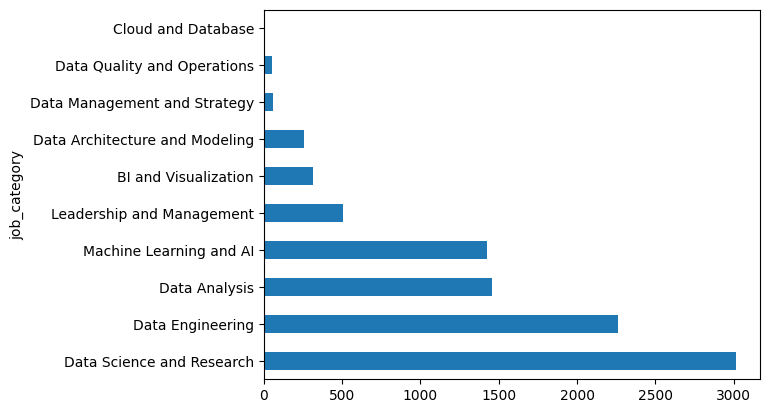

In [50]:
#Kategorik bir değişkendeki kategorilerin gözlem sayılarını basitçe görselleştirelim
df["job_category"].value_counts().plot.barh();


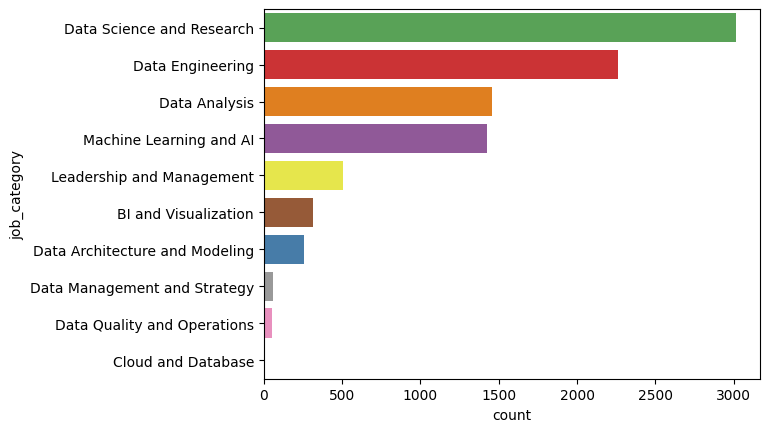

In [51]:
sns.countplot(data = df,
              y = "job_category",
              hue = "job_category",
              order = df["job_category"].value_counts().index,
              palette = "Set1");

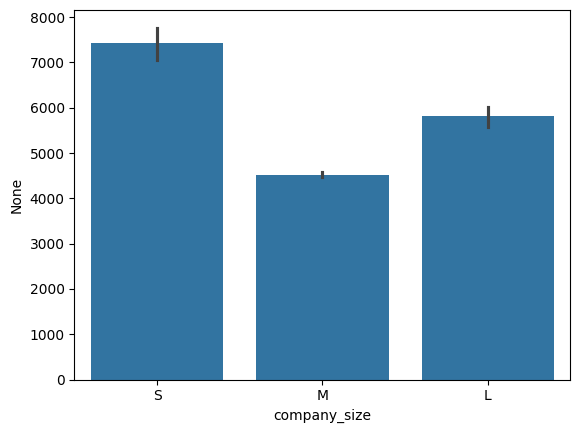

In [52]:

sns.barplot(data = df, x = "company_size", y = df.company_size.index);

#Barların üzerindeki çizgi, bir aralık ifade eder. Barlar çalıştığında barın en yüksek kısmı ilgili kategorik değişkenin ortalamasını verir
#Örnekte s kategorisinde 7000-8000 arasındadır ortalama


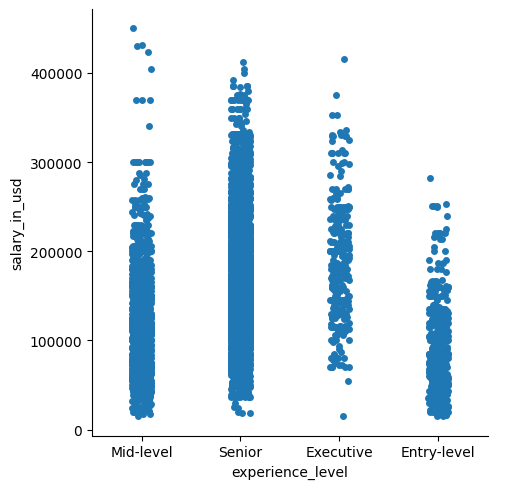

In [53]:
sns.catplot(data=df,
           x="experience_level",
           y="salary_in_usd");

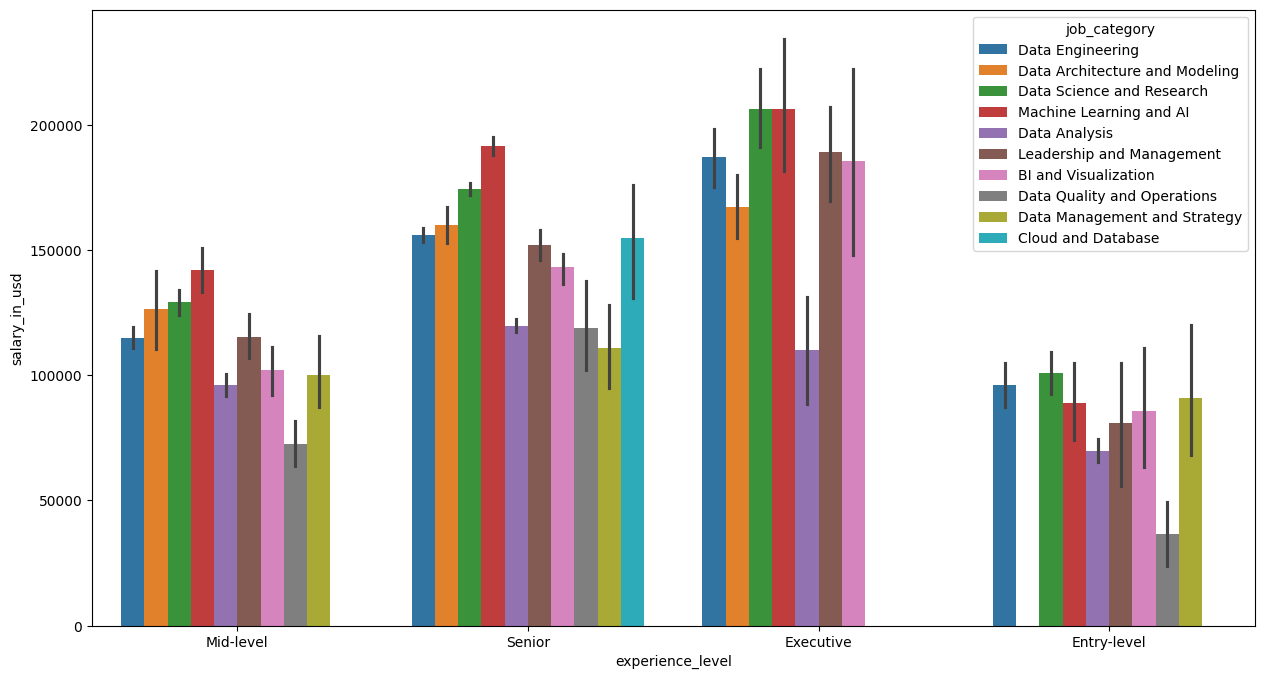

In [54]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,
            x="experience_level",
            y="salary_in_usd",
            hue="job_category");




In [55]:
#3.3 Kategorik Gruplama (groupby) İşlemleri
df.head()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


In [56]:
df_usd=df.groupby(by="job_category")["salary_in_usd"].mean().to_frame().reset_index().sort_values(by="salary_in_usd",ascending=False)
df_usd

,job_category,salary_in_usd
9,Machine Learning and AI,178925.847339
7,Data Science and Research,163758.575979
3,Data Architecture and Modeling,156002.359073
1,Cloud and Database,155000.000000
4,Data Engineering,146197.656195
8,Leadership and Management,145476.019881
0,BI and Visualization,135092.102236
2,Data Analysis,108505.721345
5,Data Management and Strategy,103139.934426
6,Data Quality and Operations,100879.472727


In [57]:

df.groupby(by = ['job_category', 'work_setting'])['salary_in_usd'].mean().to_frame().reset_index().sort_values(by = "salary_in_usd", ascending = False)[:5]

,job_category,work_setting,salary_in_usd
21,Leadership and Management,Hybrid,221464.000000
25,Machine Learning and AI,In-person,190794.558952
7,Data Architecture and Modeling,Hybrid,174851.500000
9,Data Architecture and Modeling,Remote,170680.586466
19,Data Science and Research,In-person,169128.239037


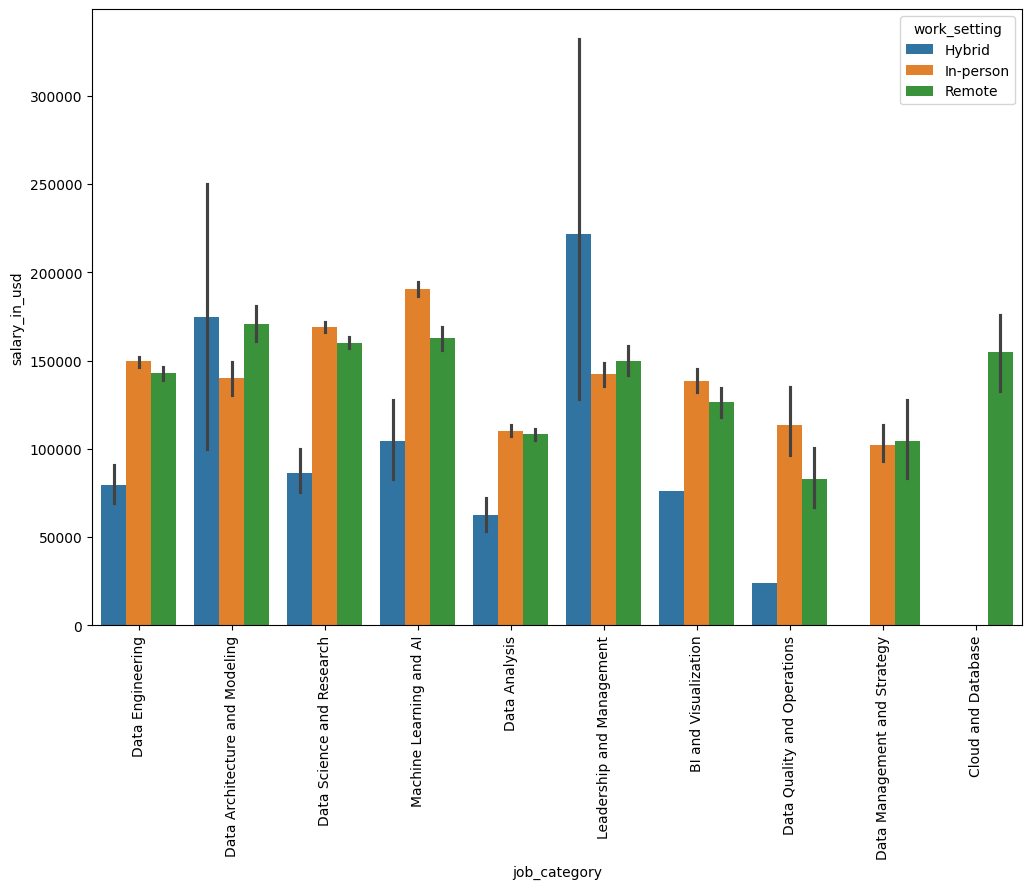

In [58]:
plt.figure(figsize = (12, 8))
plt.xticks(rotation = 90)
sns.barplot(data = df, x = "job_category", y = "salary_in_usd", hue = "work_setting");

In [59]:
#Herhangi bir ülke için, iş kategorisi bazında kaç adt kayıt var?

df_location = df.groupby(by = "company_location")["job_category"].value_counts().to_frame().reset_index().sort_values(by = "count", ascending = False)
df_location_usa =df_location[df_location["company_location"]=="Germany"]
df_location_usa

,company_location,job_category,count
54,Germany,Data Science and Research,30
55,Germany,Machine Learning and AI,21
56,Germany,Data Engineering,13
57,Germany,Data Analysis,7
58,Germany,Leadership and Management,1


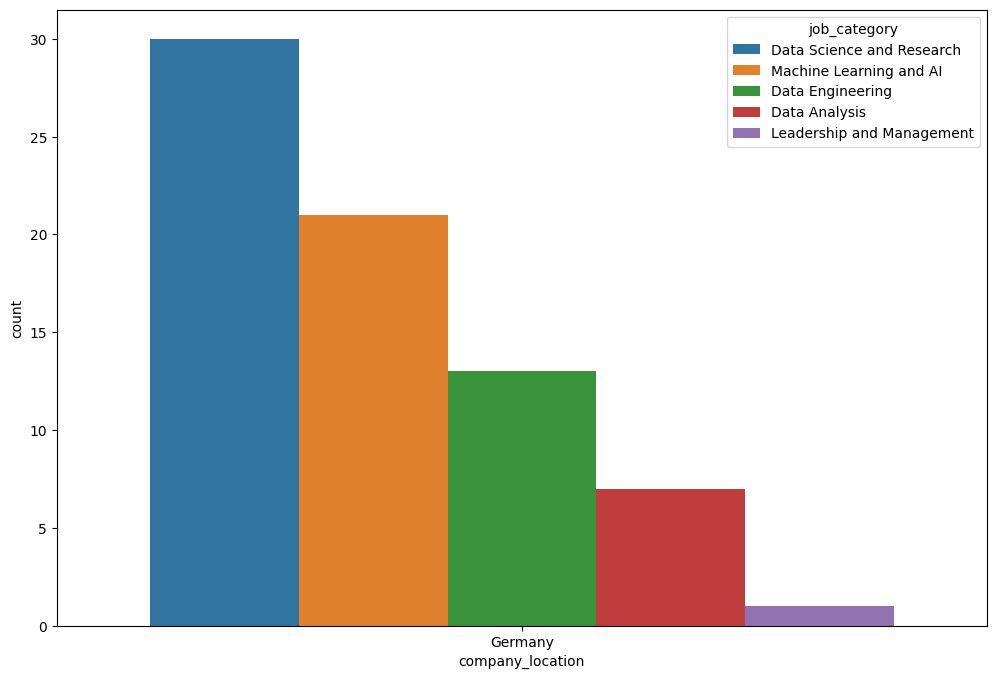

In [60]:
plt.figure(figsize=(12,8))
sns.barplot(data=df_location_usa, 
           x="company_location",
           y="count",
           hue="job_category");

4. Sürekli Değişken Analizi

In [61]:
#4.1 Sürekli Değişkenlerin İncelenmesi
#Veri setindeki numerik kolonları seçmek için aşağıdaki yapıyı kullanabiliriz

df_numerical=df.select_dtypes(include=["float64","int64"])
df_numerical.head()

,work_year,salary,salary_in_usd
0,2023,88000,95012
1,2023,186000,186000
2,2023,81800,81800
3,2023,212000,212000
4,2023,93300,93300


In [62]:
df_numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,9355.0,2022.760449,0.519470,2020.0,2023.0,2023.0,2023.0,2023.0
salary,9355.0,149927.981293,63608.835387,14000.0,105200.0,143860.0,187000.0,450000.0
salary_in_usd,9355.0,150299.495564,63177.372024,15000.0,105700.0,143000.0,186723.0,450000.0


In [63]:
#Bir veri setindeki numerik kolonların istatistiksel bilgilerine erişmek için basitçe bu tarz bir fonksiyon yazabiliriz

def give_stats(dataframe: pd.DataFrame) -> None:
    """Prints statistical information for numerical columns.

    Args:
        dataframe (pd.DataFrame): DataFrame object.
    
    Return:
        None
    
    """

    num_df = dataframe.select_dtypes(include = ["float", "int"])

    for col in num_df.columns:
        print(f"**********{col}**********")
        print(f"Mean value of {col} is {num_df[col].mean():.2f}")
        print(f"Std value of {col} is {num_df[col].std():.2f}")
        print(f"Max value of {col} is {num_df[col].max()}")
        print(f"Min value of {col} is {num_df[col].min()}")
        print(f"Count value of {col} is {num_df[col].count()}")
        print(f"Median value of {col} is {num_df[col].median()}\n")

In [64]:
give_stats(dataframe=df)

**********work_year**********
Mean value of work_year is 2022.76
Std value of work_year is 0.52
Max value of work_year is 2023
Min value of work_year is 2020
Count value of work_year is 9355
Median value of work_year is 2023.0

**********salary**********
Mean value of salary is 149927.98
Std value of salary is 63608.84
Max value of salary is 450000
Min value of salary is 14000
Count value of salary is 9355
Median value of salary is 143860.0

**********salary_in_usd**********
Mean value of salary_in_usd is 150299.50
Std value of salary_in_usd is 63177.37
Max value of salary_in_usd is 450000
Min value of salary_in_usd is 15000
Count value of salary_in_usd is 9355
Median value of salary_in_usd is 143000.0



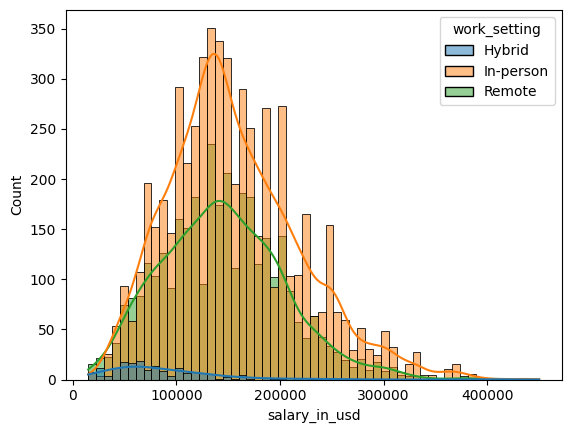

In [65]:
#Numerik bir kolonun dağılımını görmek için histogram kullanırız
sns.histplot(data =df, 
            x="salary_in_usd",
            kde=True,
            hue="work_setting");

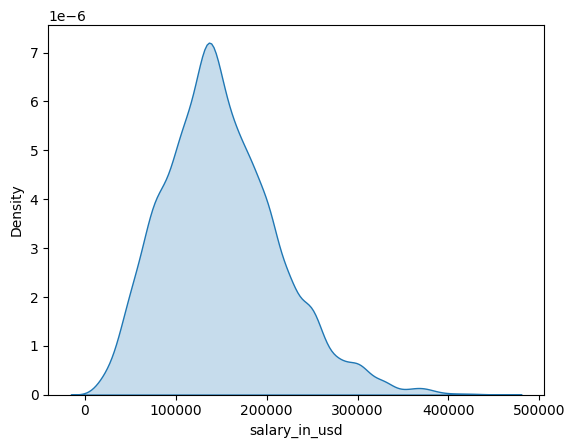

In [66]:
#kdeplot ise ilgili numerik değişkenin yoğunluğunu gösterir
sns.kdeplot(df["salary_in_usd"], fill=True);

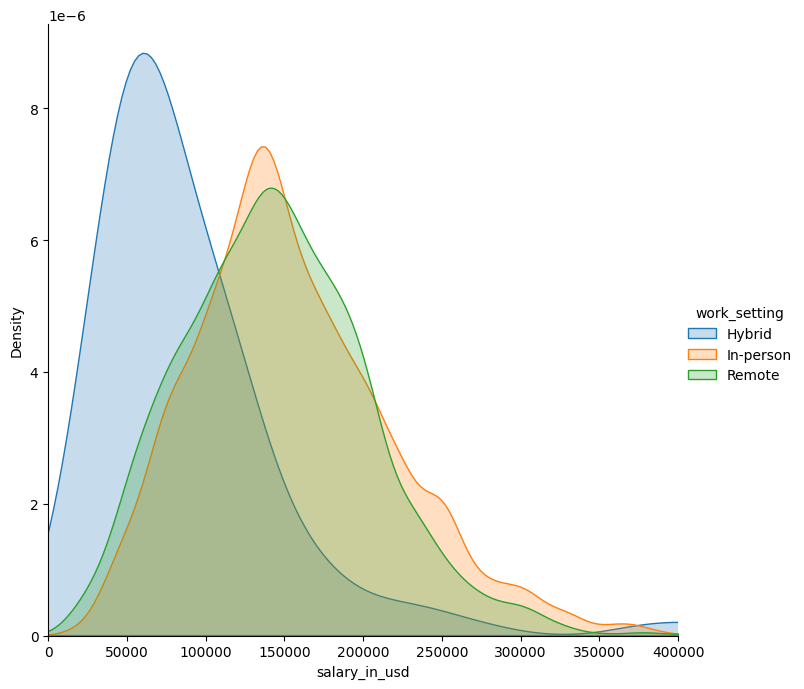

In [67]:
#FaceGrid kullarak kategorik kırılımda yoğunluk gözlemleyebiliriz.FacetGrid(data = df,
sns.FacetGrid(data = df,
              hue = "work_setting",
              height = 7,
              xlim = (0, 400000)).map(sns.kdeplot, "salary_in_usd", fill = True).add_legend();                

<Figure size 1200x800 with 0 Axes>

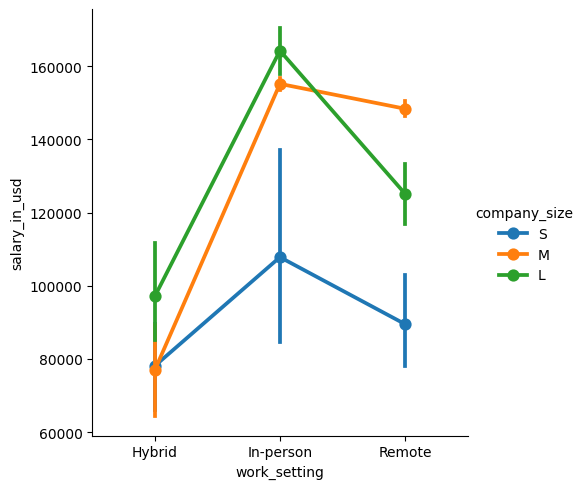

In [68]:
#Catplot ile numerik bir değişkenin kategori bazda ve kırılımdaki dağılımı görebiliriz.
plt.figure(figsize=(12,8))
sns.catplot(data=df,
           x="work_setting",
           y="salary_in_usd",
           hue="company_size",
           kind="point");

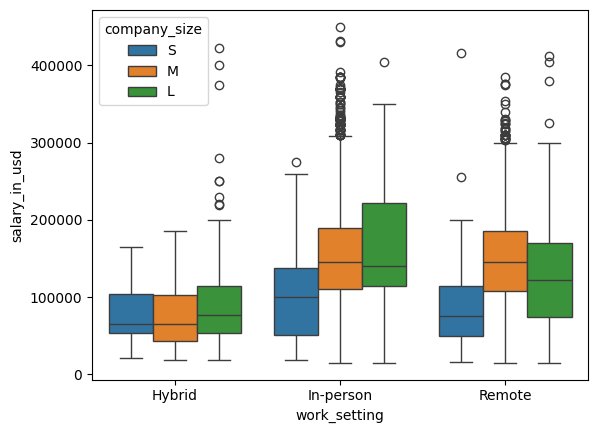

In [69]:
#Boxplot kategorik olarka numerik dağılımı gösteri, çeyreklik değerler ve IQR'a göre aykırı değerler de boxplot ile gözlemlenebilir.
sns.boxplot(data=df,
           x="work_setting",
           y="salary_in_usd",
           hue="company_size");

5.Aykırı Değer Analizi(Outliers)

In [70]:
df=df_.copy()

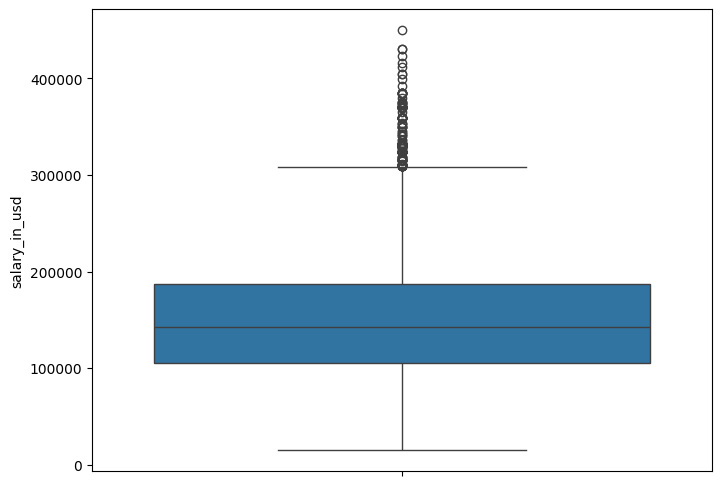

In [71]:
#Bir değişkendeki IQR'a göre aykırı gözlemleri boxplot kullarak görselleştirelim
#Inter Quartile Range : Outlier tespit etmek için en sık başvurulan yöntemlerden biridir.
plt.figure(figsize=(8,6))
sns.boxplot(data=df,
            y=df["salary_in_usd"],
            orient="v");

In [72]:
df_salary_in_usd=df["salary_in_usd"]
df_salary_in_usd

0        95012
1       186000
2        81800
3       212000
4        93300
         ...  
9350    165000
9351    412000
9352    151000
9353    105000
9354    100000
Name: salary_in_usd, Length: 9355, dtype: int64

In [73]:
#Quantile değerlerin belirlenmesi
Q1=df_salary_in_usd.quantile(0.25)
Q3=df_salary_in_usd.quantile(0.75)

print(Q1)
print(Q3)

# IQR değerin belirlenmesi.
IQR = Q3-Q1
print(IQR)

# Alt ve üst sınırların belirlenmesi.
lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

105700.0
186723.0
81023.0


In [74]:
#Upper_fence üzerinde kalan aykırı gözlemlerin index değerlerini, daha sonra kullanmak üzere bir değişkende tutabiliriz

outlier_idx = df_salary_in_usd[df_salary_in_usd > upper_fence].index

outlier_idx


Index([ 263,  415,  515,  537,  589,  810,  884,  888,  967,  995,
       ...
       8070, 8218, 9054, 9103, 9108, 9157, 9287, 9304, 9348, 9351],
      dtype='int64', length=158)

In [75]:
df_salary_in_usd[df_salary_in_usd > upper_fence]

263     319000
415     331640
515     336300
537     323300
589     324000
         ...  
9157    450000
9287    416000
9304    325000
9348    423000
9351    412000
Name: salary_in_usd, Length: 158, dtype: int64